# Exploration — France Electricity Forecasting

Dataset: `data/processed/dataset.parquet`, built by the ingestion pipeline (see `docs/decisions/0002-ingestion-pipeline-design.md`). Personal exploration notebook — see `docs/decisions/0003-exploratory-notebook-design.md` for scope and intent.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/dataset.parquet")
df = df.set_index("date_heure").sort_index()
df.shape

(23252, 8)

## 1. Vue d'ensemble et qualité des données

In [2]:
print(f"Période : {df.index.min()} -> {df.index.max()}")
print(f"Nombre de lignes : {len(df)}")
print(f"Doublons d'index : {df.index.duplicated().sum()}")
print()
print("Taux de valeurs manquantes par colonne :")
print(df.isna().mean().sort_values(ascending=False))

Période : 2024-02-01 00:00:00+00:00 -> 2026-09-26 23:00:00+00:00
Nombre de lignes : 23252
Doublons d'index : 0

Taux de valeurs manquantes par colonne :
consommation             0.000344
prevision_j              0.000086
prevision_j1             0.000000
temperature_nationale    0.000000
est_ferie                0.000000
vacances_zone_a          0.000000
vacances_zone_b          0.000000
vacances_zone_c          0.000000
dtype: float64


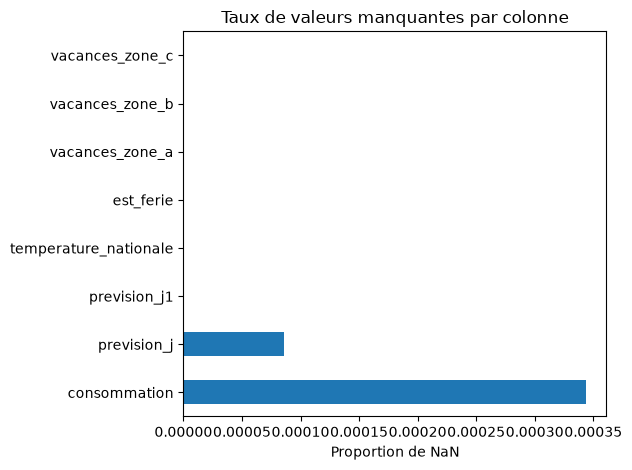

In [3]:
df.isna().mean().sort_values(ascending=False).plot.barh(
    title="Taux de valeurs manquantes par colonne"
)
plt.xlabel("Proportion de NaN")
plt.tight_layout()
plt.show()

Les valeurs manquantes actuelles sont concentrées à la toute fin du jeu de données (les heures les plus récentes, pas encore consolidées par RTE) — un phénomène différent, et permanent tant que le pipeline tourne, des trous historiques documentés dans `CLAUDE.md` (transitions DST, décalage de publication autour du 30 juin 2026).

## 2. Distribution et saisonnalité de la consommation

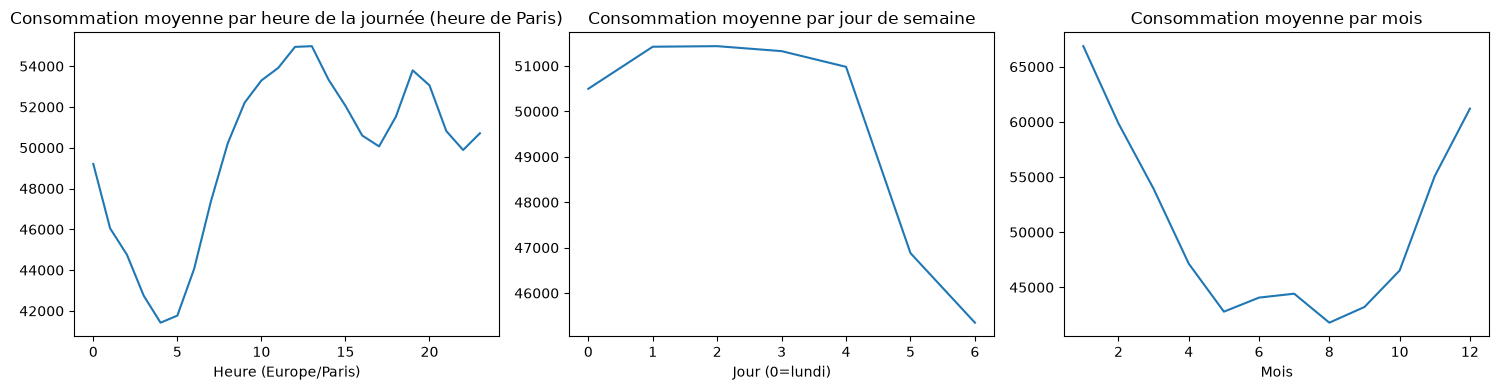

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

heure_locale = df.index.tz_convert("Europe/Paris").hour
df.groupby(heure_locale)["consommation"].mean().plot(
    ax=axes[0], title="Consommation moyenne par heure de la journée (heure de Paris)"
)
axes[0].set_xlabel("Heure (Europe/Paris)")

df.groupby(df.index.dayofweek)["consommation"].mean().plot(
    ax=axes[1], title="Consommation moyenne par jour de semaine"
)
axes[1].set_xlabel("Jour (0=lundi)")

df.groupby(df.index.month)["consommation"].mean().plot(
    ax=axes[2], title="Consommation moyenne par mois"
)
axes[2].set_xlabel("Mois")

plt.tight_layout()
plt.show()